In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TASK 1: Create synthetic dataset and build model
np.random.seed(42)
n_samples = 60
area = np.random.randint(800, 3500, n_samples)
bedrooms = np.random.randint(1, 6, n_samples)
age = np.random.randint(0, 30, n_samples)
# Price formula with some random noise
price = (area * 0.05) + (bedrooms * 10) - (age * 0.5) + np.random.normal(0, 5, n_samples)

df = pd.DataFrame({'area_sqft': area, 'num_bedrooms': bedrooms, 'age_years': age, 'price_lakhs': price})

X = df[['area_sqft', 'num_bedrooms', 'age_years']]
y = df['price_lakhs']

model = LinearRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficients: {dict(zip(X.columns, model.coef_.round(2)))}")

predictions = model.predict(X)
comparison = pd.DataFrame({'Actual': y, 'Predicted': predictions})
print("\nFirst 5 Actual vs. Predicted values:")
print(comparison.head())

Matplotlib is building the font cache; this may take a moment.


Intercept: -3.15
Coefficients: {'area_sqft': np.float64(0.05), 'num_bedrooms': np.float64(10.22), 'age_years': np.float64(-0.46)}

First 5 Actual vs. Predicted values:
       Actual   Predicted
0  107.522418  109.869531
1  147.254316  149.168700
2  109.764682  107.355952
3  110.919695  111.130167
4  154.974694  154.630088


In [3]:
# TASK 2: Evaluation
mae = mean_absolute_error(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))
r2 = r2_score(y, predictions)

print(f"\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")
# MAE and RMSE represent the average prediction error in lakhs (lower is better),
# while R2 indicates that our model explains {r2:.1%} of the variance in house prices,
# suggesting a very strong fit for this dataset.



MAE: 3.71, RMSE: 4.56, R2: 0.99


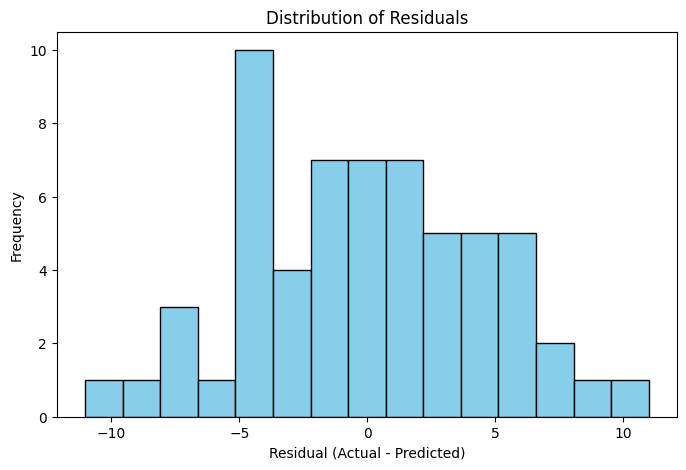

In [4]:
# TASK 3: Residuals Analysis
residuals = y - predictions

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=15, color='skyblue', edgecolor='black')
plt.title('Distribution of Residuals')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

# A residual is the vertical distance between an actual data point and the regression line (the error).
# The bell-shaped, centered histogram suggests our residuals are normally distributed around zero,
# which indicates that the model's errors are random and the linear assumption is appropriate.